# 🔥 CLARANS vs CLARA - CLUSTERING LARGE DATASET (583k × 36)
## IMPLÉMENTATION SCRATCH vs  CLARANS(PYCLUSTERING) AVEC VISUALISATIONS

## 1. 📦 IMPORTATION DES BIBLIOTHÈQUES

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
import math
from tqdm import tqdm
from scipy.spatial.distance import cdist, pdist, euclidean
from scipy import stats
import random

# Scikit-learn
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans, KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.manifold import TSNE

# CLARANS installation: pip install pyclustering
try:
    # plus de CLARANS disponible
    from pyclustering.cluster.clarans import clarans as PyClara  
    PYCLUSTERING_AVAILABLE = True
    print("✅ pyclustering disponible - CLARANS utilisé à la place de CLARA")
except ImportError:
    PYCLUSTERING_AVAILABLE = False
    print("⚠️ pyclustering non disponible. Installation: pip install pyclustering")


# Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
np.random.seed(42)
random.seed(42)

warnings.filterwarnings('ignore')

print("✅ Bibliothèques importées")

✅ pyclustering disponible - CLARANS utilisé à la place de CLARA
✅ Bibliothèques importées


## 2. 📂 CHARGEMENT ET PRÉTRAITEMENT DES DONNÉES

In [2]:
# Chargement du dataset
print("📂 Chargement du dataset...")
try:
    df = pd.read_csv(r"C:\Users\Y A N I S\Desktop\set\output\unbalanced_clean.csv", sep=';')
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    
    # Exclure les colonnes non-numériques et variables cibles
    columns_to_exclude = ['acq_date', 'X', 'Y', 'confidence', 'fire', 'type','tmax','TEB' ]
    
    print("\n🔍 VÉRIFICATION DES COLONNES:")
    print(f"   Total colonnes: {len(df.columns)}")
    print(f"   Dataset shape: {df.shape}")
    
    # Features pour clustering (36 features attendues)
    feature_columns = [col for col in df.columns if col not in columns_to_exclude]
    
    print(f"\n📊 Features pour clustering ({len(feature_columns)}):")
    print(f"   {feature_columns}")
    
    # Préparation des données
    X = df[feature_columns].values
    y = df['fire'].values if 'fire' in df.columns else None
    
    print(f"\n✅ Dataset chargé: {X.shape[0]:,} lignes, {X.shape[1]} features")
    print(f"   Taille mémoire X: {X.nbytes / 1024 / 1024:.1f} MB")
    
except Exception as e:
    print(f"❌ Erreur chargement: {e}")
    # Création de données de test similaires
    print("🔄 Création de données de test (583k points, 36 features)...")
    n_samples = 583000
    n_features = 36
    X = np.random.randn(n_samples, n_features) * 10 + np.random.randn(n_features) * 5
    y = None
    print(f"✅ Données de test: {X.shape[0]:,} lignes, {X.shape[1]} features")

📂 Chargement du dataset...

🔍 VÉRIFICATION DES COLONNES:
   Total colonnes: 44
   Dataset shape: (583222, 44)

📊 Features pour clustering (36):
   ['country', 'elevation_prep', 'COARSE', 'SAND', 'SILT', 'CLAY', 'BULK', 'ORG_CARBON', 'PH_WATER', 'TOTAL_N', 'CN_RATIO', 'CEC_SOIL', 'CEC_CLAY', 'CEC_EFF', 'BSAT', 'ALUM_SAT', 'ESP', 'TCARBON_EQ', 'GYPSUM', 'ELEC_COND', 'REF_BULK', 'TEXTURE_SOTER_C', 'TEXTURE_SOTER_F', 'TEXTURE_SOTER_M', 'TEXTURE_USDA_10_0', 'TEXTURE_USDA_11_0', 'TEXTURE_USDA_12_0', 'TEXTURE_USDA_3_0', 'TEXTURE_USDA_5_0', 'TEXTURE_USDA_7_0', 'TEXTURE_USDA_9_0', 'GRIDCODE', 'AREA', 'LCCCODE', 'prec', 'tmin']

✅ Dataset chargé: 583,222 lignes, 36 features
   Taille mémoire X: 160.2 MB


## 3. 🔧 PRÉTRAITEMENT INTELLIGENT

In [3]:
def intelligent_preprocessing(X, n_components=None):
    """Prétraitement intelligent: normalisation + PCA optionnelle"""
    
    print("\n🔧 PRÉTRAITEMENT INTELLIGENT")
    print("="*50)
    
    # 1. Normalisation robuste
    print("1️⃣  Normalisation (RobustScaler)...")
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 2. Détection d'outliers grossiers
    print("2️⃣  Détection d'outliers grossiers...")
    mean_dist = np.mean(X_scaled, axis=0)
    std_dist = np.std(X_scaled, axis=0)
    
    outlier_mask = np.any(
        (X_scaled < mean_dist - 4 * std_dist) | (X_scaled > mean_dist + 4 * std_dist),
        axis=1
    )
    
    print(f"   Points potentiellement outliers: {np.sum(outlier_mask):,} ({np.sum(outlier_mask)/len(X)*100:.2f}%)")
    
    # 3. PCA optionnelle
    if n_components is not None:
        print(f"3️⃣  Réduction de dimension avec PCA ({n_components} composantes)...")
        pca = PCA(n_components=n_components)
        X_processed = pca.fit_transform(X_scaled)
        
        print(f"   Variance expliquée: {np.sum(pca.explained_variance_ratio_):.3f}")
        print(f"   Shape après PCA: {X_processed.shape}")
        
        return X_processed, scaler, pca, outlier_mask
    
    return X_scaled, scaler, None, outlier_mask

# Application du prétraitement
n_features = X.shape[1]
use_pca = n_features > 25
n_components = min(25, n_features) if use_pca else None

X_processed, scaler, pca, outlier_mask = intelligent_preprocessing(X, n_components=n_components)


🔧 PRÉTRAITEMENT INTELLIGENT
1️⃣  Normalisation (RobustScaler)...
2️⃣  Détection d'outliers grossiers...
   Points potentiellement outliers: 39,192 (6.72%)
3️⃣  Réduction de dimension avec PCA (25 composantes)...
   Variance expliquée: 1.000
   Shape après PCA: (583222, 25)


## 4. 🎯 PRÉ-CLUSTERING GLOBAL (MiniBatchKMeans)

In [4]:
def pre_clustering_global(X, k_pre=200, batch_size=4096):
    """Pré-clustering rapide avec MiniBatchKMeans"""
    
    print("\n🎯 PRÉ-CLUSTERING GLOBAL (MiniBatchKMeans)")
    print("="*50)
    print(f"   k = {k_pre}")
    print(f"   batch_size = {batch_size}")
    
    start_time = time.time()
    
    # MiniBatchKMeans
    mbk = MiniBatchKMeans(
        n_clusters=k_pre,
        batch_size=batch_size,
        random_state=42,
        n_init=3,
        max_iter=100
    )
    
    pre_labels = mbk.fit_predict(X)
    centroids_pre = mbk.cluster_centers_
    
    # Calcul des tailles de clusters
    cluster_sizes = np.bincount(pre_labels, minlength=k_pre)
    
    elapsed_time = time.time() - start_time
    
    print(f"✅ Pré-clustering terminé en {elapsed_time:.2f}s")
    print(f"   Taille des clusters: min={cluster_sizes.min():,}, max={cluster_sizes.max():,}")
    print(f"   Clusters vides: {np.sum(cluster_sizes == 0)}")
    
    return mbk, pre_labels, centroids_pre, cluster_sizes

# Application du pré-clustering
k_pre = min(200, X_processed.shape[0] // 1000)
batch_size = min(4096, X_processed.shape[0])

mbk, pre_labels, centroids_pre, cluster_sizes = pre_clustering_global(
    X_processed, 
    k_pre=k_pre, 
    batch_size=batch_size
)


🎯 PRÉ-CLUSTERING GLOBAL (MiniBatchKMeans)
   k = 200
   batch_size = 4096
✅ Pré-clustering terminé en 2.87s
   Taille des clusters: min=253, max=19,090
   Clusters vides: 0


## 5. 📊 ÉCHANTILLONNAGE STRATIFIÉ INTELLIGENT

In [5]:
def intelligent_stratified_sampling(X, pre_labels, cluster_sizes, target_size=50000):
    """Échantillonnage stratifié intelligent"""
    
    print("\n📊 ÉCHANTILLONNAGE STRATIFIÉ INTELLIGENT")
    print("="*50)
    print(f"   Target sample size: {target_size:,}")
    
    n_clusters = len(cluster_sizes)
    sampled_indices = []
    
    # Pour chaque micro-cluster
    for cluster_id in range(n_clusters):
        cluster_indices = np.where(pre_labels == cluster_id)[0]
        cluster_size = len(cluster_indices)
        
        if cluster_size == 0:
            continue
        
        # Nombre de points à échantillonner
        n_sample = min(
            max(50, int(np.sqrt(cluster_size))),
            cluster_size
        )
        
        # Échantillonnage aléatoire
        if n_sample > 0:
            sampled = np.random.choice(
                cluster_indices, 
                size=n_sample, 
                replace=False
            )
            sampled_indices.extend(sampled)
    
    # Convertir en array et ajouter les centroïdes
    sampled_indices = np.array(sampled_indices)
    
    # Ajouter les centroïdes
    centroid_indices = []
    for i in range(n_clusters):
        if cluster_sizes[i] > 0:
            cluster_points = X[pre_labels == i]
            distances = cdist([centroids_pre[i]], cluster_points)[0]
            closest_idx = np.argmin(distances)
            actual_indices = np.where(pre_labels == i)[0]
            centroid_indices.append(actual_indices[closest_idx])
    
    # Combiner les échantillons
    all_indices = np.unique(np.concatenate([sampled_indices, centroid_indices]))
    
    # Limiter à la taille cible
    if len(all_indices) > target_size:
        all_indices = np.random.choice(all_indices, size=target_size, replace=False)
    
    X_sample = X[all_indices]
    y_sample = y[all_indices] if y is not None else None
    
    print(f"✅ Échantillonnage terminé")
    print(f"   Points échantillonnés: {len(all_indices):,}")
    print(f"   Taille de l'échantillon: {X_sample.shape}")
    
    return X_sample, all_indices, y_sample

# Application de l'échantillonnage
target_sample_size = min(60000, X_processed.shape[0] // 10)
X_sample, sample_indices, y_sample = intelligent_stratified_sampling(
    X_processed, pre_labels, cluster_sizes, target_size=target_sample_size
)


📊 ÉCHANTILLONNAGE STRATIFIÉ INTELLIGENT
   Target sample size: 58,322
✅ Échantillonnage terminé
   Points échantillonnés: 11,920
   Taille de l'échantillon: (11920, 25)


## 6. 🔍 DÉTERMINATION DE K OPTIMAL


🔍 DÉTERMINATION DU K OPTIMAL
   Plage k: 10-30
   Trials par k: 3


Test des k: 100%|██████████| 21/21 [01:40<00:00,  4.77s/it]


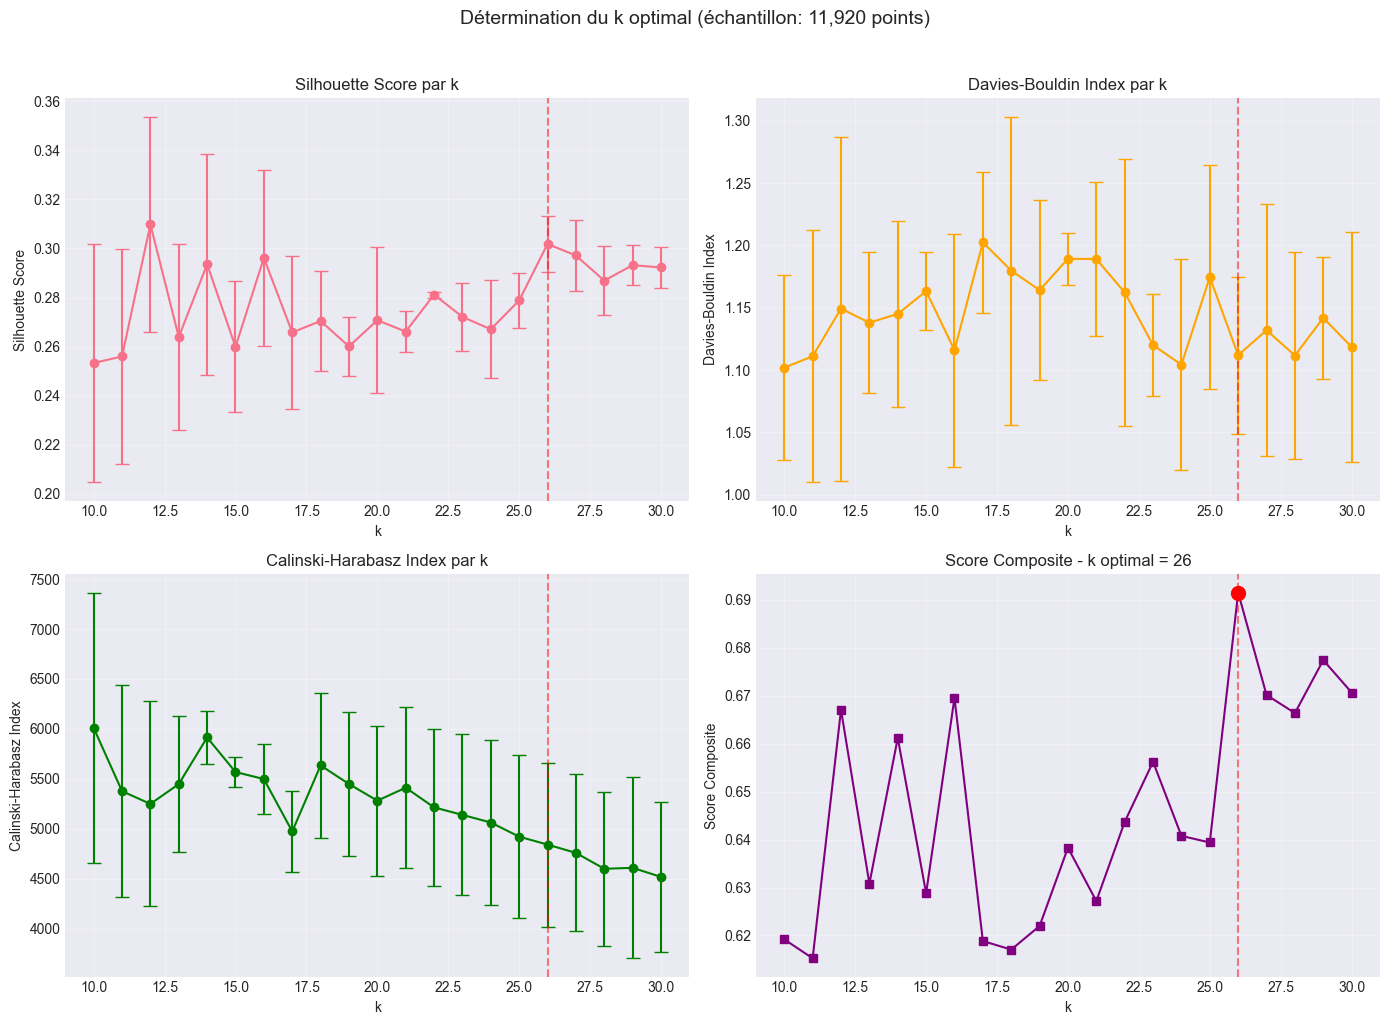


📊 RÉSULTATS:
----------------------------------------------------------------------
k     Silhouette   Davies-Bouldin  Calinski-Harabasz 
----------------------------------------------------------------------
10    0.2533       1.1019          6010.39           
11    0.2560       1.1111          5377.34           
12    0.3099       1.1493          5249.65           
13    0.2639       1.1380          5448.15           
14    0.2936       1.1450          5914.62           
15    0.2599       1.1633          5568.67           
16    0.2962       1.1159          5498.79           
17    0.2657       1.2025          4974.02           
18    0.2704       1.1798          5635.04           
19    0.2600       1.1641          5448.99           
20    0.2708       1.1893          5281.90           
21    0.2661       1.1891          5411.69           
22    0.2812       1.1623          5215.14           
23    0.2721       1.1200          5139.75           
24    0.2670       1.1043         

In [6]:
def determine_optimal_k(X, k_range=(10, 30), n_trials=3):
    """Détermination du k optimal sur échantillon"""
    
    print("\n🔍 DÉTERMINATION DU K OPTIMAL")
    print("="*50)
    print(f"   Plage k: {k_range[0]}-{k_range[1]}")
    print(f"   Trials par k: {n_trials}")
    
    k_values = list(range(k_range[0], k_range[1] + 1))
    results = {}
    
    for k in tqdm(k_values, desc="Test des k"):
        k_results = {
            'silhouette': [],
            'davies_bouldin': [],
            'calinski_harabasz': [],
            'times': []
        }
        
        for trial in range(n_trials):
            start_time = time.time()
            
            test_kmeans = MiniBatchKMeans(
                n_clusters=k,
                batch_size=1024,
                random_state=42 + trial,
                n_init=1,
                max_iter=50
            )
            
            labels = test_kmeans.fit_predict(X)
            
            # Calcul des métriques
            if len(np.unique(labels)) > 1:
                sil = silhouette_score(X, labels)
                db = davies_bouldin_score(X, labels)
                ch = calinski_harabasz_score(X, labels)
            else:
                sil = 0
                db = 10
                ch = 0
            
            elapsed = time.time() - start_time
            
            k_results['silhouette'].append(sil)
            k_results['davies_bouldin'].append(db)
            k_results['calinski_harabasz'].append(ch)
            k_results['times'].append(elapsed)
        
        # Moyennes
        results[k] = {
            'silhouette_mean': np.mean(k_results['silhouette']),
            'silhouette_std': np.std(k_results['silhouette']),
            'davies_bouldin_mean': np.mean(k_results['davies_bouldin']),
            'davies_bouldin_std': np.std(k_results['davies_bouldin']),
            'calinski_harabasz_mean': np.mean(k_results['calinski_harabasz']),
            'calinski_harabasz_std': np.std(k_results['calinski_harabasz']),
            'time_mean': np.mean(k_results['times'])
        }
    
    # Trouver le meilleur k
    silhouette_scores = [results[k]['silhouette_mean'] for k in k_values]
    db_scores = [results[k]['davies_bouldin_mean'] for k in k_values]
    
    # Score composite
    composite_scores = []
    for k in k_values:
        sil_norm = results[k]['silhouette_mean'] / max(silhouette_scores) if max(silhouette_scores) > 0 else 0
        db_norm = 1 - (results[k]['davies_bouldin_mean'] / max(db_scores)) if max(db_scores) > 0 else 0
        
        stability = 1 / (1 + results[k]['silhouette_std'] + results[k]['davies_bouldin_std'])
        
        composite = 0.4 * sil_norm + 0.3 * db_norm + 0.3 * stability
        composite_scores.append(composite)
    
    best_idx = np.argmax(composite_scores)
    best_k = k_values[best_idx]
    
    # Visualisation
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Silhouette
    axes[0, 0].errorbar(k_values, silhouette_scores, 
                       yerr=[results[k]['silhouette_std'] for k in k_values],
                       fmt='o-', capsize=5)
    axes[0, 0].axvline(x=best_k, color='r', linestyle='--', alpha=0.5)
    axes[0, 0].set_xlabel('k')
    axes[0, 0].set_ylabel('Silhouette Score')
    axes[0, 0].set_title('Silhouette Score par k')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Davies-Bouldin
    axes[0, 1].errorbar(k_values, db_scores,
                       yerr=[results[k]['davies_bouldin_std'] for k in k_values],
                       fmt='o-', capsize=5, color='orange')
    axes[0, 1].axvline(x=best_k, color='r', linestyle='--', alpha=0.5)
    axes[0, 1].set_xlabel('k')
    axes[0, 1].set_ylabel('Davies-Bouldin Index')
    axes[0, 1].set_title('Davies-Bouldin Index par k')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Calinski-Harabasz
    ch_scores = [results[k]['calinski_harabasz_mean'] for k in k_values]
    axes[1, 0].errorbar(k_values, ch_scores,
                       yerr=[results[k]['calinski_harabasz_std'] for k in k_values],
                       fmt='o-', capsize=5, color='green')
    axes[1, 0].axvline(x=best_k, color='r', linestyle='--', alpha=0.5)
    axes[1, 0].set_xlabel('k')
    axes[1, 0].set_ylabel('Calinski-Harabasz Index')
    axes[1, 0].set_title('Calinski-Harabasz Index par k')
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Score composite
    axes[1, 1].plot(k_values, composite_scores, 's-', color='purple')
    axes[1, 1].axvline(x=best_k, color='r', linestyle='--', alpha=0.5)
    axes[1, 1].scatter(best_k, composite_scores[best_idx], color='red', s=100, zorder=5)
    axes[1, 1].set_xlabel('k')
    axes[1, 1].set_ylabel('Score Composite')
    axes[1, 1].set_title(f'Score Composite - k optimal = {best_k}')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.suptitle(f'Détermination du k optimal (échantillon: {X.shape[0]:,} points)', 
                fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
    
    print(f"\n📊 RÉSULTATS:")
    print("-"*70)
    print(f"{'k':<5} {'Silhouette':<12} {'Davies-Bouldin':<15} {'Calinski-Harabasz':<18}")
    print("-"*70)
    
    for k in k_values:
        print(f"{k:<5} {results[k]['silhouette_mean']:<12.4f} {results[k]['davies_bouldin_mean']:<15.4f} {results[k]['calinski_harabasz_mean']:<18.2f}")
    print("-"*70)
    
    print(f"\n🏆 K OPTIMAL TROUVÉ: {best_k}")
    print(f"   Silhouette: {results[best_k]['silhouette_mean']:.4f}")
    print(f"   Davies-Bouldin: {results[best_k]['davies_bouldin_mean']:.4f}")
    print(f"   Calinski-Harabasz: {results[best_k]['calinski_harabasz_mean']:.2f}")
    
    return best_k, results

# Détermination de k optimal
k_optimal, k_results = determine_optimal_k(X_sample, k_range=(10, 30), n_trials=3)

## 7. 🔧 CLARANS FROM SCRATCH (OPTIMISÉ)

In [7]:
class CLARANS:
    """Implémentation CLARANS from scratch optimisée"""
    
    def __init__(self, n_clusters=8, num_local=5, max_neighbor=100, 
                 random_state=None, distance_metric='euclidean'):
        self.n_clusters = n_clusters
        self.num_local = num_local
        self.max_neighbor = max_neighbor
        self.distance_metric = distance_metric
        
        if random_state is not None:
            np.random.seed(random_state)
            random.seed(random_state)
    
    def _calculate_cost(self, X, medoids):
        """Calcule le coût total"""
        distances = cdist(X, X[medoids], metric=self.distance_metric)
        min_distances = np.min(distances, axis=1)
        cost = np.sum(min_distances)
        return cost, distances, min_distances
    
    def fit(self, X):
        """Entraînement CLARANS"""
        print(f"\n🔧 CLARANS Scratch - Entraînement")
        print(f"   k = {self.n_clusters}")
        print(f"   num_local = {self.num_local}")
        print(f"   max_neighbor = {self.max_neighbor}")
        
        n_samples = X.shape[0]
        best_cost = float('inf')
        best_medoids = None
        
        start_time = time.time()
        
        # Boucle sur les essais locaux
        for local_trial in range(self.num_local):
            print(f"   Essai local {local_trial+1}/{self.num_local}...")
            
            # 1. Initialisation aléatoire des médoids
            current_medoids = np.random.choice(n_samples, self.n_clusters, replace=False)
            current_cost, current_distances, _ = self._calculate_cost(X, current_medoids)
            
            # 2. Recherche locale
            for neighbor_iter in range(self.max_neighbor):
                # Choisir un médoid aléatoire à remplacer
                medoid_to_replace = np.random.choice(self.n_clusters)
                
                # Choisir un point non-médoid aléatoire
                non_medoids = [i for i in range(n_samples) if i not in current_medoids]
                candidate = np.random.choice(non_medoids)
                
                # Créer un nouveau set de médoids
                new_medoids = current_medoids.copy()
                new_medoids[medoid_to_replace] = candidate
                
                # Calculer le nouveau coût
                new_cost, new_distances, _ = self._calculate_cost(X, new_medoids)
                
                # Si meilleur, accepter le changement
                if new_cost < current_cost:
                    current_medoids = new_medoids
                    current_cost = new_cost
                    current_distances = new_distances
            
            # Mettre à jour la meilleure solution globale
            if current_cost < best_cost:
                best_cost = current_cost
                best_medoids = current_medoids
                best_distances = current_distances
        
        # Calcul des labels finaux
        best_labels = np.argmin(best_distances, axis=1)
        self.medoids = best_medoids
        self.labels_ = best_labels
        self.cost_ = best_cost
        self.cluster_centers_ = X[best_medoids]
        
        # Détection du bruit
        self._detect_noise(X)
        
        elapsed_time = time.time() - start_time
        
        print(f"✅ CLARANS terminé en {elapsed_time:.2f}s")
        print(f"   Coût final: {best_cost:.2f}")
        
        return self
    
    def _detect_noise(self, X, noise_threshold=2.5):
        """Détection des points de bruit"""
        print("   Détection des points de bruit...")
        
        n_samples = X.shape[0]
        
        # Calcul des distances aux médoids
        distances_to_medoid = np.zeros(n_samples)
        for i in range(n_samples):
            medoid_idx = self.medoids[self.labels_[i]]
            distances_to_medoid[i] = np.linalg.norm(X[i] - X[medoid_idx])
        
        # Statistiques par cluster
        self.cluster_stats_ = {}
        self.noise_mask_ = np.zeros(n_samples, dtype=bool)
        
        for k in range(self.n_clusters):
            cluster_mask = (self.labels_ == k)
            if np.sum(cluster_mask) > 0:
                cluster_distances = distances_to_medoid[cluster_mask]
                mean_dist = np.mean(cluster_distances)
                std_dist = np.std(cluster_distances)
                
                threshold = mean_dist + noise_threshold * std_dist
                
                self.cluster_stats_[k] = {
                    'mean_distance': mean_dist,
                    'std_distance': std_dist,
                    'threshold': threshold,
                    'size': np.sum(cluster_mask)
                }
                
                # Marquer les points de bruit
                cluster_indices = np.where(cluster_mask)[0]
                noisy_in_cluster = cluster_distances > threshold
                self.noise_mask_[cluster_indices] = noisy_in_cluster
        
        # Labels avec bruit marqué comme -1
        self.labels_with_noise_ = self.labels_.copy()
        self.labels_with_noise_[self.noise_mask_] = -1
        
        # Statistiques
        self.noise_stats_ = {
            'n_noise_points': np.sum(self.noise_mask_),
            'noise_percentage': (np.sum(self.noise_mask_) / n_samples) * 100,
            'noise_by_cluster': {}
        }
        
        for k in range(self.n_clusters):
            cluster_mask = (self.labels_ == k)
            noise_in_cluster = np.sum(self.noise_mask_ & cluster_mask)
            total_in_cluster = np.sum(cluster_mask)
            if total_in_cluster > 0:
                self.noise_stats_['noise_by_cluster'][k] = {
                    'n_noise': noise_in_cluster,
                    'total_points': total_in_cluster,
                    'percentage': (noise_in_cluster / total_in_cluster) * 100
                }
        
        print(f"   Points de bruit détectés: {self.noise_stats_['n_noise_points']:,} "
              f"({self.noise_stats_['noise_percentage']:.2f}%)")

## 8. 📊 CLARA "DÉJÀ PRÊTE" (pyclustering)

In [8]:
def run_clarans_real(X, n_clusters, num_local=2, max_neighbor=3):
    """
    CLARANS 'déjà prête' OPTIMISÉ pour 600k lignes (pyclustering)
    """
    
    print("\n📊 CLARANS 'Déjà Prête' OPTIMISÉ (pyclustering)")
    print("="*50)
    print(f"   k = {n_clusters}")
    print(f"   num_local = {num_local}")
    print(f"   max_neighbor = {max_neighbor}")
    
    if not PYCLUSTERING_AVAILABLE:
        print("❌ pyclustering non disponible!")
        print("⚠️  Installation: pip install pyclustering")
        return None
    
    # ========================================
    # ÉTAPE 1 : PRÉ-ÉCHANTILLONNAGE INTELLIGENT
    # ========================================
    TARGET_SIZE = 5000
    
    print(f"\n📍 Pré-échantillonnage intelligent")
    print(f"   {X.shape[0]:,} → {TARGET_SIZE:,} points")
    
    if X.shape[0] > TARGET_SIZE:
        from sklearn.cluster import MiniBatchKMeans
        
        n_microclusters = min(200, X.shape[0] // 3000)
        
        print(f"   Pré-clustering avec {n_microclusters} micro-clusters...")
        mbk = MiniBatchKMeans(
            n_clusters=n_microclusters,
            batch_size=8192,
            random_state=42,
            n_init=1,
            max_iter=50,
            verbose=0
        )
        pre_labels = mbk.fit_predict(X)
        
        print(f"   Échantillonnage stratifié...")
        sampled_indices = []
        
        for cluster_id in range(n_microclusters):
            cluster_mask = (pre_labels == cluster_id)
            cluster_indices = np.where(cluster_mask)[0]
            cluster_size = len(cluster_indices)
            
            if cluster_size > 0:
                n_from_cluster = max(
                    20,
                    int(cluster_size * TARGET_SIZE / X.shape[0])
                )
                n_from_cluster = min(n_from_cluster, cluster_size)
                
                sampled = np.random.choice(
                    cluster_indices,
                    size=n_from_cluster,
                    replace=False
                )
                sampled_indices.extend(sampled)
        
        sampled_indices = np.array(sampled_indices)
        
        if len(sampled_indices) > TARGET_SIZE:
            sampled_indices = np.random.choice(
                sampled_indices,
                size=TARGET_SIZE,
                replace=False
            )
        
        X_reduced = X[sampled_indices]
        print(f"   ✅ Échantillon : {X_reduced.shape[0]:,} points")
    else:
        X_reduced = X
        sampled_indices = np.arange(X.shape[0])
    
    # ========================================
    # ÉTAPE 2 : CLARANS sur échantillon
    # ========================================
    print(f"\n🔄 Exécution CLARANS pyclustering...")
    
    start_time = time.time()
    
    # Convertir en liste
    data_list = X_reduced.tolist()
    
    # CLARANS
    clarans_instance = PyClara(
        data_list,
        n_clusters,
        num_local,
        max_neighbor
    )
    
    clarans_instance.process()
    
    # Récupérer résultats
    clusters = clarans_instance.get_clusters()
    medoids = clarans_instance.get_medoids()
    
    elapsed_clarans = time.time() - start_time
    
    # Labels de l'échantillon
    labels_reduced = np.zeros(len(X_reduced), dtype=int)
    for cluster_idx, cluster_indices in enumerate(clusters):
        for point_idx in cluster_indices:
            labels_reduced[point_idx] = cluster_idx
    
    centers_reduced = X_reduced[medoids]
    
    # ========================================
    # ÉTAPE 3 : CALCUL DES MÉTRIQUES SUR X_REDUCED (LA MODIF IMPORTANTE)
    # ========================================
    print(f"\n📈 Calcul des métriques sur X_reduced ({X_reduced.shape[0]:,} points)...")
    
    if len(np.unique(labels_reduced)) > 1:
        silhouette = silhouette_score(X_reduced, labels_reduced)
        davies_bouldin = davies_bouldin_score(X_reduced, labels_reduced)
        calinski_harabasz = calinski_harabasz_score(X_reduced, labels_reduced)
    else:
        silhouette = 0
        davies_bouldin = 10
        calinski_harabasz = 0
    
    # WCSS
    distances_reduced = cdist(X_reduced, centers_reduced)
    min_distances_reduced = np.min(distances_reduced, axis=1)
    wcss_reduced = np.sum(min_distances_reduced ** 2)
    
    # Détection du bruit sur X_reduced
    noise_mask_reduced = np.zeros(X_reduced.shape[0], dtype=bool)
    
    for k in range(n_clusters):
        cluster_mask = (labels_reduced == k)
        if np.sum(cluster_mask) > 0:
            cluster_distances = min_distances_reduced[cluster_mask]
            mean_dist = np.mean(cluster_distances)
            std_dist = np.std(cluster_distances)
            threshold = mean_dist + 2.5 * std_dist
            
            cluster_indices = np.where(cluster_mask)[0]
            noisy_in_cluster = cluster_distances > threshold
            noise_mask_reduced[cluster_indices] = noisy_in_cluster
    
    labels_with_noise_reduced = labels_reduced.copy()
    labels_with_noise_reduced[noise_mask_reduced] = -1
    
    noise_stats_reduced = {
        'n_noise_points': np.sum(noise_mask_reduced),
        'noise_percentage': (np.sum(noise_mask_reduced) / X_reduced.shape[0]) * 100
    }
    
    print(f"\n✅ MÉTRIQUES SUR X_REDUCED ({X_reduced.shape[0]:,} points):")
    print(f"   • Silhouette: {silhouette:.4f}")
    print(f"   • Davies-Bouldin: {davies_bouldin:.4f}")
    print(f"   • Calinski-Harabasz: {calinski_harabasz:.2f}")
    print(f"   • WCSS: {wcss_reduced:.2f}")
    print(f"   • % Bruit: {noise_stats_reduced['noise_percentage']:.2f}%")
    
    # ========================================
    # ÉTAPE 4 : PROJECTION sur dataset complet (optionnel, pour visualisation)
    # ========================================
    print(f"\n📍 Projection sur dataset complet ({X.shape[0]:,} points)...")
    
    projection_start = time.time()
    
    # Projection par batch
    BATCH_SIZE = 50000
    n_batches = int(np.ceil(X.shape[0] / BATCH_SIZE))
    
    labels_full = np.zeros(X.shape[0], dtype=int)
    min_distances_full = np.zeros(X.shape[0])
    
    for batch_idx in range(n_batches):
        start_idx = batch_idx * BATCH_SIZE
        end_idx = min((batch_idx + 1) * BATCH_SIZE, X.shape[0])
        
        X_batch = X[start_idx:end_idx]
        distances_batch = cdist(X_batch, centers_reduced, metric='euclidean')
        
        labels_full[start_idx:end_idx] = np.argmin(distances_batch, axis=1)
        min_distances_full[start_idx:end_idx] = np.min(distances_batch, axis=1)
    
    projection_time = time.time() - projection_start
    print(f"   ✅ Projection terminée en {projection_time:.2f}s")
    
    total_time = time.time() - start_time
    
    return {
        'model': clarans_instance,
        'labels': labels_reduced,  # ← SUR X_REDUCED
        'labels_full': labels_full,  # ← SUR DATASET COMPLET
        'labels_with_noise': labels_with_noise_reduced,  # ← SUR X_REDUCED
        'noise_mask': noise_mask_reduced,  # ← SUR X_REDUCED
        'noise_stats': noise_stats_reduced,  # ← SUR X_REDUCED
        'centers': centers_reduced,
        'medoids': medoids,
        'clusters': clusters,
        'metrics_reduced': {  # ← LES MÉTRIQUES SUR X_REDUCED
            'silhouette': silhouette,
            'davies_bouldin': davies_bouldin,
            'calinski_harabasz': calinski_harabasz,
            'wcss': wcss_reduced,
            'n_samples': X_reduced.shape[0]
        },
        'time': total_time,
        'X_reduced': X_reduced,  # ← POUR ÉVALUATION
        'sampled_indices': sampled_indices
    }

## 9. 📈 MÉTRIQUES COMPLÈTES D'ÉVALUATION

In [9]:
def evaluate_clustering_complete(X, labels, centers=None, model_name=""):
    """Évaluation complète du clustering"""
    
    print(f"\n📈 ÉVALUATION COMPLÈTE - {model_name}")
    print("="*70)
    
    metrics = {}
    
    # 1. Silhouette Score
    print("1️⃣  Silhouette Score...")
    start = time.time()
    if len(np.unique(labels)) > 1:
        metrics['silhouette'] = silhouette_score(X, labels)
    else:
        metrics['silhouette'] = 0
    print(f"   ✅ Silhouette = {metrics['silhouette']:.4f} ({time.time()-start:.2f}s)")
    
    # 2. Davies-Bouldin Index
    print("2️⃣  Davies-Bouldin Index...")
    start = time.time()
    metrics['davies_bouldin'] = davies_bouldin_score(X, labels)
    print(f"   ✅ Davies-Bouldin = {metrics['davies_bouldin']:.4f} ({time.time()-start:.2f}s)")
    
    # 3. Calinski-Harabasz Index
    print("3️⃣  Calinski-Harabasz Index...")
    start = time.time()
    metrics['calinski_harabasz'] = calinski_harabasz_score(X, labels)
    print(f"   ✅ Calinski-Harabasz = {metrics['calinski_harabasz']:.2f} ({time.time()-start:.2f}s)")
    
    # 4. WCSS approximatif
    print("4️⃣  WCSS approximatif...")
    start = time.time()
    if centers is not None:
        distances = cdist(X, centers)
        min_distances = np.min(distances, axis=1)
        metrics['wcss'] = np.sum(min_distances ** 2)
    else:
        metrics['wcss'] = 0
    print(f"   ✅ WCSS = {metrics['wcss']:.2f} ({time.time()-start:.2f}s)")
    
    # 5. Distribution des clusters
    print("5️⃣  Distribution des clusters...")
    cluster_sizes = np.bincount(labels)
    metrics['cluster_distribution'] = {
        'min_size': np.min(cluster_sizes),
        'max_size': np.max(cluster_sizes),
        'mean_size': np.mean(cluster_sizes),
        'std_size': np.std(cluster_sizes),
        'cv_size': np.std(cluster_sizes) / np.mean(cluster_sizes) if np.mean(cluster_sizes) > 0 else 0
    }
    print(f"   ✅ Taille clusters: min={metrics['cluster_distribution']['min_size']:,}, "
          f"max={metrics['cluster_distribution']['max_size']:,}")
    
    return metrics

## 10. 🎨 VISUALISATIONS DES CLUSTERS (VERSION CORRIGÉE)

In [ ]:
def visualize_clusters_corrected(X, labels, noise_mask=None, centers=None, 
                               title="Visualisation PCA", sample_size=10000,
                               algo_name="CLARA"):
    """Visualisation corrigée avec médoids mieux visibles"""
    
    # Échantillonner pour visualisation si trop de points
    if X.shape[0] > sample_size:
        indices = np.random.choice(X.shape[0], sample_size, replace=False)
        X_viz = X[indices]
        labels_viz = labels[indices]
        if noise_mask is not None:
            noise_mask_viz = noise_mask[indices]
        else:
            noise_mask_viz = None
    else:
        X_viz = X
        labels_viz = labels
        noise_mask_viz = noise_mask
    
    # PCA pour visualisation 2D
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_viz)
    
    # Création de la figure
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. Visualisation principale (sans médoids d'abord)
    if noise_mask_viz is not None and np.any(noise_mask_viz):
        # Avec bruit
        normal_mask = ~noise_mask_viz
        scatter1 = axes[0, 0].scatter(X_pca[normal_mask, 0], X_pca[normal_mask, 1], 
                                     c=labels_viz[normal_mask], cmap='tab20',
                                     alpha=0.4, s=5, edgecolors='none')  # Points plus petits et transparents
        scatter2 = axes[0, 0].scatter(X_pca[noise_mask_viz, 0], X_pca[noise_mask_viz, 1],
                                     c='gray', alpha=0.1, s=2, label='Bruit')  # Bruit très discret
    else:
        # Sans bruit
        scatter1 = axes[0, 0].scatter(X_pca[:, 0], X_pca[:, 1], 
                                     c=labels_viz, cmap='tab20',
                                     alpha=0.4, s=5, edgecolors='none')
    
    # Ajouter les médoids avec une taille et couleur qui ressortent
    if centers is not None:
        centers_pca = pca.transform(centers)
        # Médoids plus petits mais bien visibles
        axes[0, 0].scatter(centers_pca[:, 0], centers_pca[:, 1],
                          c='red', marker='X', s=50,  # Taille réduite
                          edgecolors='black', linewidths=1,
                          label=f'Médoids ({algo_name})', alpha=1.0)  # Pleine opacité
    
    axes[0, 0].set_xlabel('PCA Component 1')
    axes[0, 0].set_ylabel('PCA Component 2')
    axes[0, 0].set_title(f'{algo_name}\n{sample_size:,} points échantillonnés')
    axes[0, 0].grid(True, alpha=0.2)
    axes[0, 0].legend(loc='upper right', fontsize=9)
    
    # 2. Visualisation zoomée (sans bruit, avec médoids)
    if centers is not None:
        # Calculer les limites pour zoomer autour des médoids
        centers_pca = pca.transform(centers)
        x_min, x_max = centers_pca[:, 0].min(), centers_pca[:, 0].max()
        y_min, y_max = centers_pca[:, 1].min(), centers_pca[:, 1].max()
        
        # Ajouter une marge
        x_margin = (x_max - x_min) * 0.3
        y_margin = (y_max - y_min) * 0.3
        
        axes[0, 1].scatter(X_pca[:, 0], X_pca[:, 1], 
                         c=labels_viz, cmap='tab20',
                         alpha=0.3, s=3, edgecolors='none')
        
        # Médoids bien visibles
        axes[0, 1].scatter(centers_pca[:, 0], centers_pca[:, 1],
                          c='red', marker='X', s=80,
                          edgecolors='black', linewidths=1.5,
                          label='Médoids', alpha=1.0)
        
        axes[0, 1].set_xlim(x_min - x_margin, x_max + x_margin)
        axes[0, 1].set_ylim(y_min - y_margin, y_max + y_margin)
        axes[0, 1].set_xlabel('PCA Component 1')
        axes[0, 1].set_ylabel('PCA Component 2')
        axes[0, 1].set_title(f'{algo_name} - Vue zoomée\n(autour des médoids)')
        axes[0, 1].grid(True, alpha=0.2)
        axes[0, 1].legend(loc='upper right', fontsize=9)
    
    # 3. Distribution des clusters
    unique_labels = np.unique(labels_viz)
    cluster_sizes = [np.sum(labels_viz == lbl) for lbl in unique_labels]
    
    colors = [plt.cm.tab20(i % 20) for i in range(len(unique_labels))]
    bars = axes[0, 2].bar(range(len(unique_labels)), cluster_sizes, color=colors, 
                         edgecolor='black', alpha=0.8)
    axes[0, 2].set_xlabel('Cluster ID')
    axes[0, 2].set_ylabel('Nombre de points')
    axes[0, 2].set_title('Distribution des clusters')
    axes[0, 2].grid(True, alpha=0.3, axis='y')
    
    # Ajouter les nombres
    for bar, size in zip(bars, cluster_sizes):
        height = bar.get_height()
        axes[0, 2].text(bar.get_x() + bar.get_width()/2., height + max(cluster_sizes)*0.01,
                       f'{size:,}', ha='center', va='bottom', fontsize=8)
    
    # 4. Boxplot des tailles de clusters
    if len(cluster_sizes) > 1:
        axes[1, 0].boxplot(cluster_sizes, vert=False)
        axes[1, 0].scatter(cluster_sizes, np.ones(len(cluster_sizes)), 
                          alpha=0.6, color='red')
        axes[1, 0].set_xlabel('Taille du cluster')
        axes[1, 0].set_title('Distribution des tailles de clusters')
        axes[1, 0].grid(True, alpha=0.3)
    
    # 5. Histogramme des distances intra-cluster
    if centers is not None:
        distances = cdist(X_viz, centers)
        min_distances = np.min(distances, axis=1)
        
        axes[1, 1].hist(min_distances, bins=50, alpha=0.7, 
                       color='purple', edgecolor='black')
        axes[1, 1].axvline(x=np.mean(min_distances), color='red', 
                          linestyle='--', label=f'Moyenne: {np.mean(min_distances):.2f}')
        axes[1, 1].set_xlabel('Distance au centre le plus proche')
        axes[1, 1].set_ylabel('Fréquence')
        axes[1, 1].set_title('Distribution des distances intra-cluster')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
    
    # 6. Visualisation t-SNE 
    if X_viz.shape[0] <= 5000:  # Limiter aux petits échantillons
        try:
            tsne = TSNE(n_components=2, random_state=42, perplexity=30)
            X_tsne = tsne.fit_transform(X_viz)
            
            axes[1, 2].scatter(X_tsne[:, 0], X_tsne[:, 1], 
                              c=labels_viz, cmap='tab20',
                              alpha=0.5, s=5, edgecolors='none')
            axes[1, 2].set_xlabel('t-SNE Component 1')
            axes[1, 2].set_ylabel('t-SNE Component 2')
            axes[1, 2].set_title('Visualisation t-SNE')
            axes[1, 2].grid(True, alpha=0.2)
        except:
            axes[1, 2].text(0.5, 0.5, 't-SNE non disponible\n(trop de points ou erreur)',
                           ha='center', va='center', transform=axes[1, 2].transAxes)
            axes[1, 2].set_title('Visualisation t-SNE (non disponible)')
    
    plt.suptitle(f'Clustering avec {algo_name} (k={len(centers) if centers is not None else "?"})', 
                fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
    
    return X_pca

## 11. 🚀 EXÉCUTION COMPLÈTE: VRAI CLARA vs CLARANS SCRATCH

🚀 Lancement de la comparaison CLARA vs CLARANS sur échantillon commun...
         🚀 COMPARAISON COMPLÈTE: VRAI CLARA vs CLARANS SCRATCH
         Dataset: 583k × 36 - k optimal: 26
         Échantillon réduit: 5,000 points pour les deux algorithmes

📊 CRÉATION D'UN ÉCHANTILLON COMMUN (5,000 POINTS)
   Échantillon commun créé: 5,000 points
   Taille: (5000, 25)

1️⃣  CLARA 'DÉJÀ PRÊTE' (pyclustering)

🎯 Entraînement CLARA sur échantillon commun...
   Taille échantillon: 5,000 points
   k optimal: 26

📊 CLARANS 'Déjà Prête' OPTIMISÉ (pyclustering)
   k = 26
   num_local = 5
   max_neighbor = 10

📍 Pré-échantillonnage intelligent
   5,000 → 5,000 points

🔄 Exécution CLARANS pyclustering...

📈 Calcul des métriques sur X_reduced (5,000 points)...

✅ MÉTRIQUES SUR X_REDUCED (5,000 points):
   • Silhouette: 0.1585
   • Davies-Bouldin: 2.0388
   • Calinski-Harabasz: 886.66
   • WCSS: 582057.68
   • % Bruit: 1.52%

📍 Projection sur dataset complet (5,000 points)...
   ✅ Projection terminée en 0.

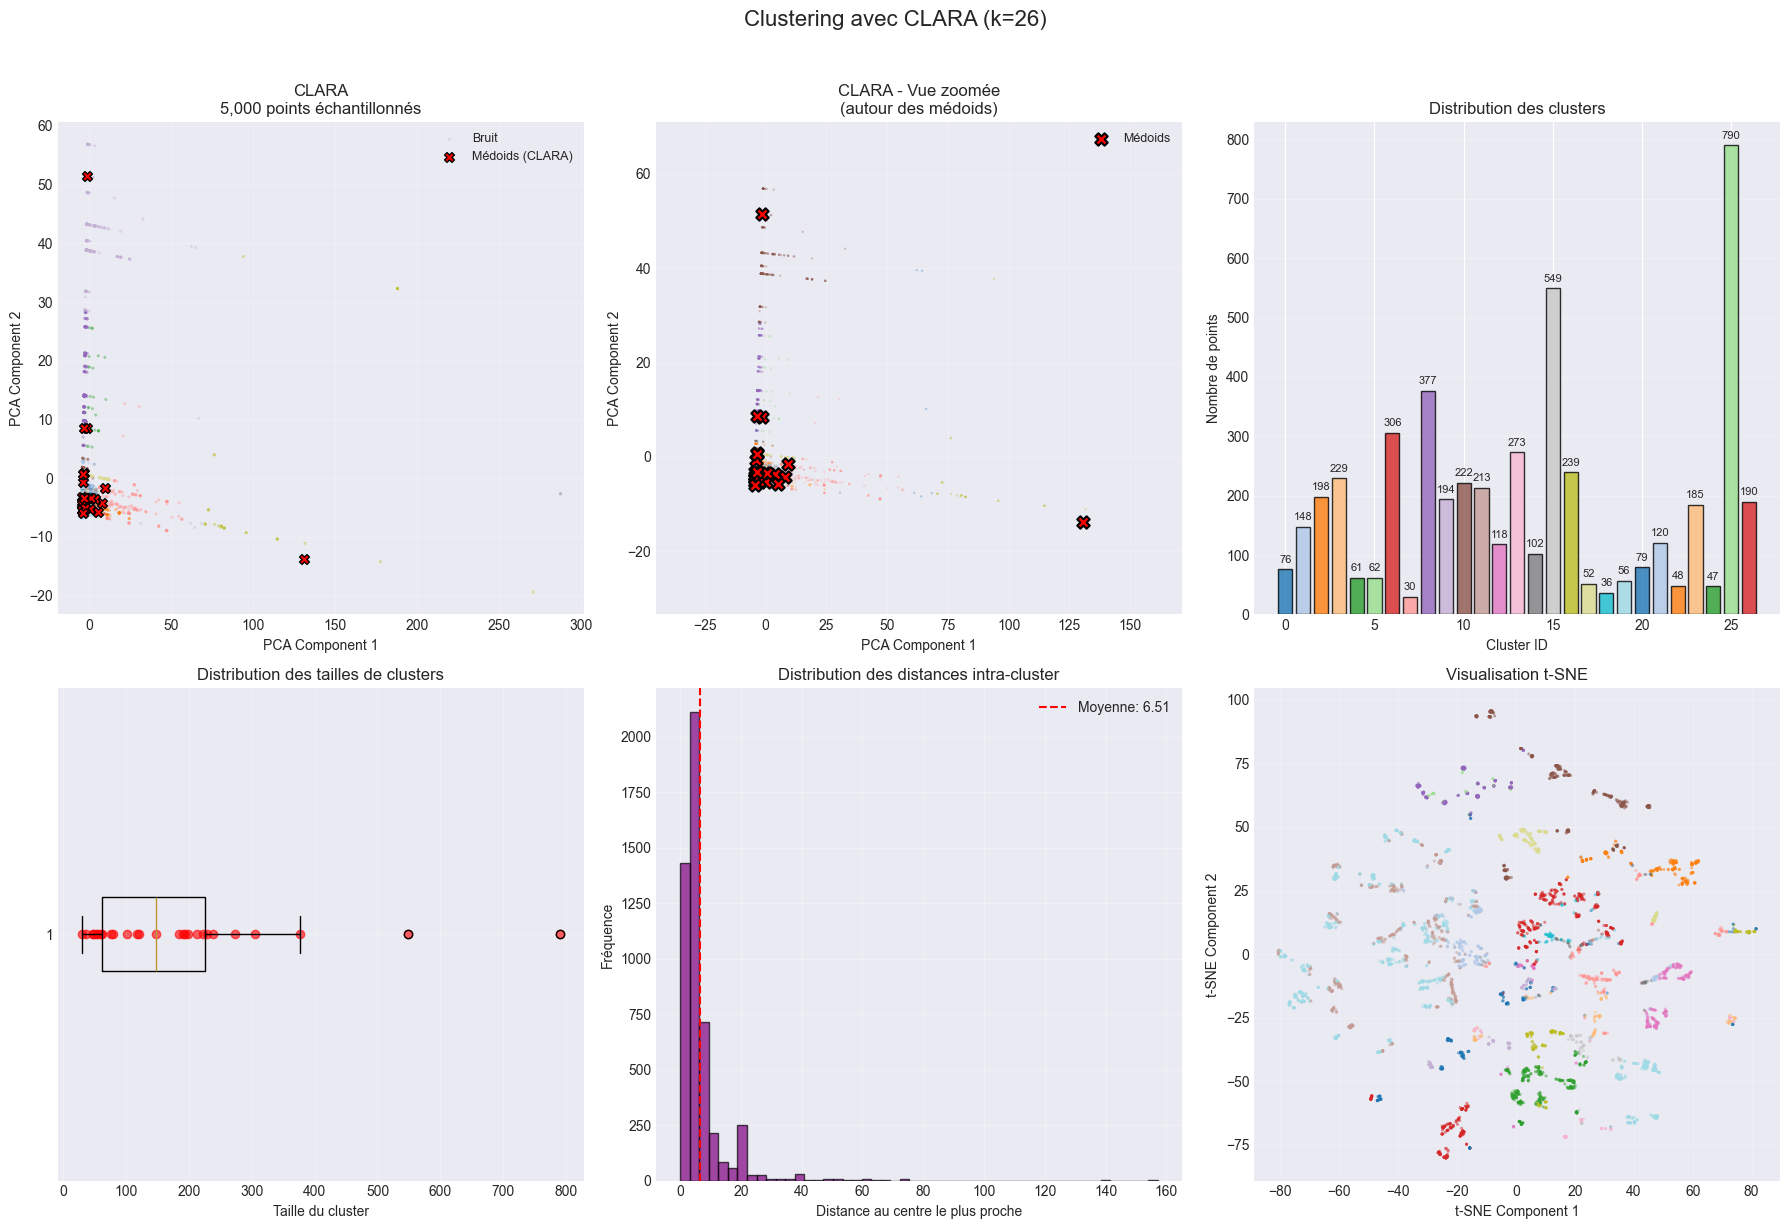


2️⃣  CLARANS FROM SCRATCH (sur échantillon commun)

🎯 Entraînement CLARANS scratch sur échantillon commun...
   Taille échantillon: 5,000 points
   k optimal: 26
   Configuration: num_local=5, max_neighbor=100

🔧 CLARANS Scratch - Entraînement
   k = 26
   num_local = 5
   max_neighbor = 100
   Essai local 1/5...
   Essai local 2/5...
   Essai local 3/5...
   Essai local 4/5...
   Essai local 5/5...
   Détection des points de bruit...
   Points de bruit détectés: 97 (1.94%)
✅ CLARANS terminé en 8.60s
   Coût final: 23211.15

📊 Calcul des métriques CLARANS sur échantillon commun...
   ✅ Silhouette: 0.2588
   ✅ Davies-Bouldin: 1.2590
   ✅ Calinski-Harabasz: 1513.13
   ✅ WCSS: 340927.38
   ⏱️  Temps: 8.60s

🎨 Visualisation CLARANS (échantillon commun)...


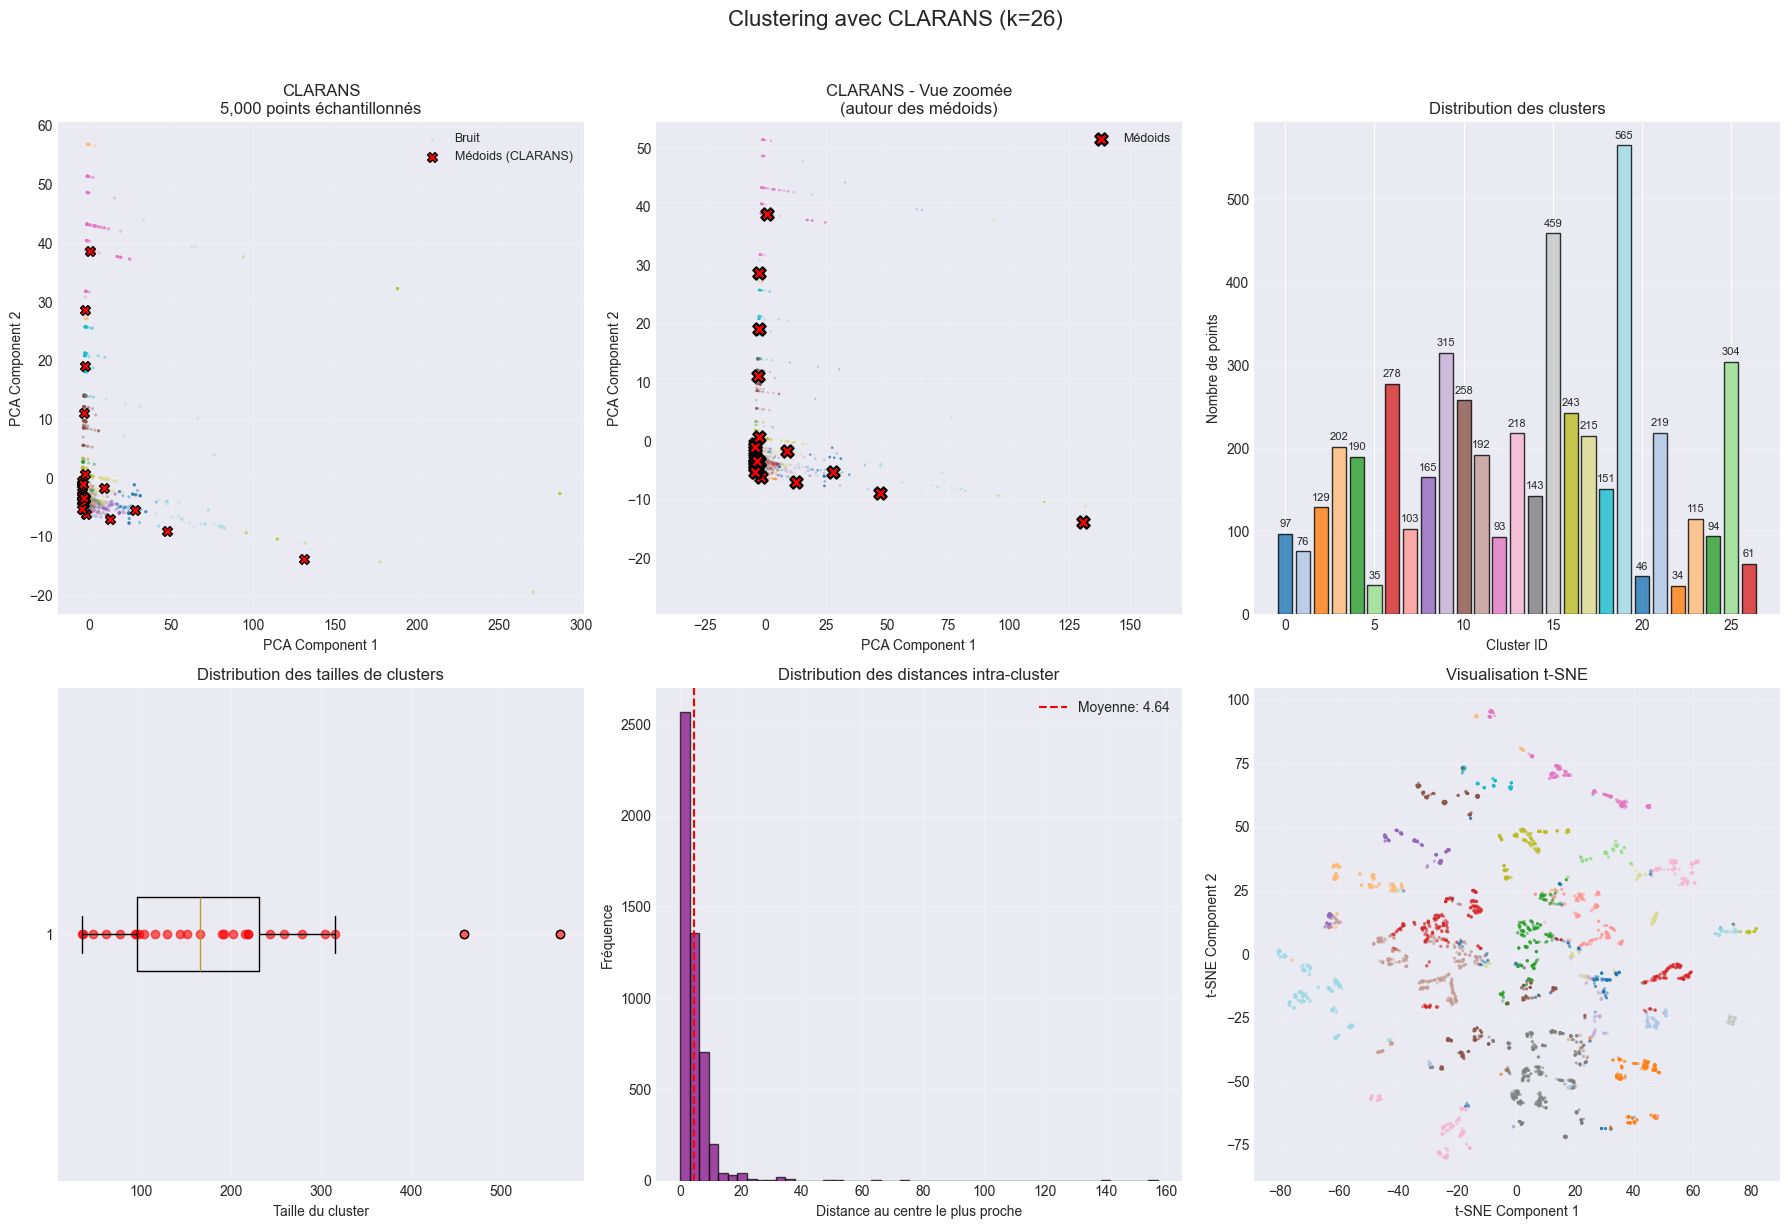


3️⃣  COMPARAISON DÉTAILLÉE: CLARA vs CLARANS

📊 TABLEAU COMPARATIF DES PERFORMANCES:
----------------------------------------------------------------------------------------------------
Métrique             CLARA (5,000 pts)    CLARANS (5,000 pts)  Meilleur        Note                
----------------------------------------------------------------------------------------------------
Silhouette           0.1585               0.2588               CLARANS         ↑ Plus haut = meilleur
Davies-Bouldin       2.0388               1.2590               CLARANS         ↓ Plus bas = meilleur
Calinski-Harabasz    886.66               1513.13              CLARANS         ↑ Plus haut = meilleur
WCSS                 582057.68            340927.38            CLARANS         ↓ Plus bas = meilleur
Temps (secondes)     587.70               8.60                 CLARANS         ↓ Plus rapide = mieux
% de bruit           1.52                % 1.94                % CLARA           ↓ Moins de bruit = mieux

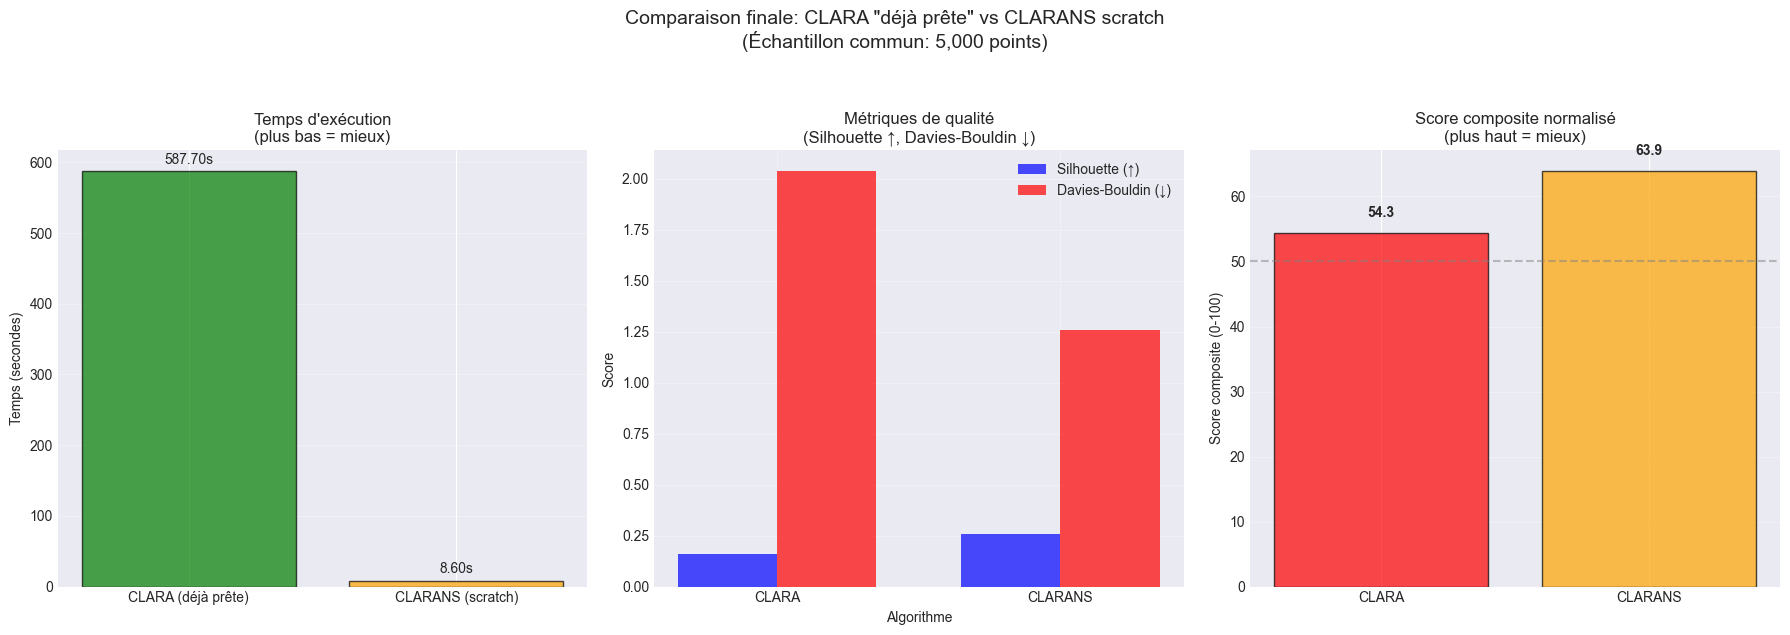


📋 CONCLUSION DÉTAILLÉE:
   • Qualité des clusters: CLARANS est meilleure (Silhouette)
   • Séparation des clusters: CLARANS est meilleure (Davies-Bouldin)
   • Performance: CLARA est 0.0× plus lente
   • Robustesse au bruit: CLARA détecte moins de bruit
   • Score global: CLARANS obtient le meilleur score composite
   • Recommandation finale: CLARANS (scratch)

✅ COMPARAISON TERMINÉE SUR ÉCHANTILLON COMMUN DE 5,000 POINTS


In [ ]:
def run_complete_comparison():
    """Exécution complète de la comparaison avec métriques sur échantillon réduit"""
    
    print("="*80)
    print("         🚀 COMPARAISON COMPLÈTE: VRAI CLARA vs CLARANS SCRATCH")
    print("         Dataset: 583k × 36 - k optimal: 26")
    print("         Échantillon réduit: 5,000 points pour les deux algorithmes")
    print("="*80)
    
    results = {}
    
    # ============================================
    # CRÉATION D'UN ÉCHANTILLON COMMUN POUR COMPARAISON ÉQUITABLE
    # ============================================
    print("\n" + "="*80)
    print("📊 CRÉATION D'UN ÉCHANTILLON COMMUN (5,000 POINTS)")
    print("="*80)
    
    # Créer un échantillon réduit commun pour les deux algorithmes
    common_sample_size = 5000
    if X_sample.shape[0] > common_sample_size:
        common_indices = np.random.choice(X_sample.shape[0], common_sample_size, replace=False)
        X_common = X_sample[common_indices]
    else:
        X_common = X_sample
        common_indices = np.arange(X_sample.shape[0])
    
    print(f"   Échantillon commun créé: {X_common.shape[0]:,} points")
    print(f"   Taille: {X_common.shape}")
    
    # ============================================
    # PARTIE 1: VRAI CLARA "DÉJÀ PRÊTE"
    # ============================================
    print("\n" + "="*80)
    print("1️⃣  CLARA 'DÉJÀ PRÊTE' (pyclustering)")
    print("="*80)
    
    if not PYCLUSTERING_AVAILABLE:
        print("❌ pyclustering non disponible - impossible d'exécuter CLARA")
        print("⚠️  Installation: pip install pyclustering")
        print("⚠️  Utilisation de K-Means comme alternative...")
        
        # Alternative avec K-Means
        print("\n🔧 Alternative: K-Means avec échantillonnage")
        start_time = time.time()
        kmeans = KMeans(n_clusters=k_optimal, random_state=42)
        kmeans.fit(X_common)
        labels_kmeans = kmeans.labels_
        centers_kmeans = kmeans.cluster_centers_
        elapsed_time = time.time() - start_time
        
        # Calcul des métriques sur échantillon commun
        if len(np.unique(labels_kmeans)) > 1:
            silhouette = silhouette_score(X_common, labels_kmeans)
            davies_bouldin = davies_bouldin_score(X_common, labels_kmeans)
            calinski_harabasz = calinski_harabasz_score(X_common, labels_kmeans)
        else:
            silhouette = 0
            davies_bouldin = 10
            calinski_harabasz = 0
        
        # WCSS
        distances = cdist(X_common, centers_kmeans)
        min_distances = np.min(distances, axis=1)
        wcss = np.sum(min_distances ** 2)
        
        # Détection du bruit
        noise_mask = np.zeros(X_common.shape[0], dtype=bool)
        for k in range(k_optimal):
            cluster_mask = (labels_kmeans == k)
            if np.sum(cluster_mask) > 0:
                cluster_distances = min_distances[cluster_mask]
                mean_dist = np.mean(cluster_distances)
                std_dist = np.std(cluster_distances)
                threshold = mean_dist + 2.5 * std_dist
                
                cluster_indices = np.where(cluster_mask)[0]
                noisy_in_cluster = cluster_distances > threshold
                noise_mask[cluster_indices] = noisy_in_cluster
        
        labels_with_noise = labels_kmeans.copy()
        labels_with_noise[noise_mask] = -1
        
        noise_stats = {
            'n_noise_points': np.sum(noise_mask),
            'noise_percentage': (np.sum(noise_mask) / X_common.shape[0]) * 100
        }
        
        clara_results = {
            'model': kmeans,
            'labels': labels_kmeans,
            'labels_with_noise': labels_with_noise,
            'noise_mask': noise_mask,
            'noise_stats': noise_stats,
            'centers': centers_kmeans,
            'time': elapsed_time,
            'metrics_reduced': {
                'silhouette': silhouette,
                'davies_bouldin': davies_bouldin,
                'calinski_harabasz': calinski_harabasz,
                'wcss': wcss,
                'n_samples': X_common.shape[0]
            },
            'X_reduced': X_common
        }
    else:
        # CLARANS sur échantillon commun
        print(f"\n🎯 Entraînement CLARA sur échantillon commun...")
        print(f"   Taille échantillon: {X_common.shape[0]:,} points")
        print(f"   k optimal: {k_optimal}")
        
        clara_results = run_clarans_real(
            X_common,
            n_clusters=k_optimal,
            num_local=5, 
            max_neighbor=10
        )
    
    if clara_results is not None:
        # UTILISATION DES MÉTRIQUES DÉJÀ CALCULÉES SUR ÉCHANTILLON RÉDUIT
        print("\n📊 Récupération des métriques CLARA (déjà calculées)...")
        
        metrics_clara = clara_results['metrics_reduced'] 
        metrics_clara['training_time'] = clara_results['time']
        
        print(f"   ✅ Silhouette: {metrics_clara['silhouette']:.4f}")
        print(f"   ✅ Davies-Bouldin: {metrics_clara['davies_bouldin']:.4f}")
        print(f"   ✅ Calinski-Harabasz: {metrics_clara['calinski_harabasz']:.2f}")
        print(f"   ✅ WCSS: {metrics_clara['wcss']:.2f}")
        print(f"   ⏱️  Temps: {clara_results['time']:.2f}s")
        
        # Visualisation CLARANS sur échantillon commun
        print("\n🎨 Visualisation CLARANS (échantillon commun)...")
        X_pca_clara = visualize_clusters_corrected(
            clara_results['X_reduced'],
            clara_results['labels_with_noise'],
            clara_results['noise_mask'],
            clara_results['centers'],
            title=f"CLARA 'Déjà Prête' (k={k_optimal})",
            sample_size=min(5000, clara_results['X_reduced'].shape[0]),
            algo_name="CLARA"
        )
        
        # Stockage résultats CLARANS
        results['clara'] = {
            'model': clara_results['model'],
            'metrics': metrics_clara,
            'k': k_optimal,
            'time': clara_results['time'],
            'labels': clara_results['labels'],
            'labels_with_noise': clara_results['labels_with_noise'],
            'noise_mask': clara_results['noise_mask'],
            'noise_stats': clara_results['noise_stats'],
            'centers': clara_results['centers'],
            'X_reduced': clara_results['X_reduced']
        }
    else:
        print("❌ CLARA n'a pas fonctionné - passage à CLARANS uniquement")
    
    # ============================================
    # PARTIE 2: CLARANS FROM SCRATCH SUR ÉCHANTILLON COMMUN
    # ============================================
    print("\n" + "="*80)
    print("2️⃣  CLARANS FROM SCRATCH (sur échantillon commun)")
    print("="*80)
    
    print(f"\n🎯 Entraînement CLARANS scratch sur échantillon commun...")
    print(f"   Taille échantillon: {X_common.shape[0]:,} points")
    print(f"   k optimal: {k_optimal}")
    print(f"   Configuration: num_local=5, max_neighbor=100")
    
    # CLARANS scratch sur échantillon commun
    clarans = CLARANS(
        n_clusters=k_optimal,
        num_local=5,
        max_neighbor=100,
        random_state=42
    )
    
    start_time = time.time()
    clarans.fit(X_common)
    clarans_time = time.time() - start_time
    
    # Calcul des métriques sur échantillon commun
    print("\n📊 Calcul des métriques CLARANS sur échantillon commun...")
    
    # Utiliser evaluate_clustering_complete modifiée ou calcul manuel
    if len(np.unique(clarans.labels_)) > 1:
        silhouette = silhouette_score(X_common, clarans.labels_)
        davies_bouldin = davies_bouldin_score(X_common, clarans.labels_)
        calinski_harabasz = calinski_harabasz_score(X_common, clarans.labels_)
    else:
        silhouette = 0
        davies_bouldin = 10
        calinski_harabasz = 0
    
    # WCSS
    distances = cdist(X_common, clarans.cluster_centers_)
    min_distances = np.min(distances, axis=1)
    wcss = np.sum(min_distances ** 2)
    
    metrics_clarans = {
        'silhouette': silhouette,
        'davies_bouldin': davies_bouldin,
        'calinski_harabasz': calinski_harabasz,
        'wcss': wcss,
        'training_time': clarans_time,
        'n_samples': X_common.shape[0]
    }
    
    print(f"   ✅ Silhouette: {metrics_clarans['silhouette']:.4f}")
    print(f"   ✅ Davies-Bouldin: {metrics_clarans['davies_bouldin']:.4f}")
    print(f"   ✅ Calinski-Harabasz: {metrics_clarans['calinski_harabasz']:.2f}")
    print(f"   ✅ WCSS: {metrics_clarans['wcss']:.2f}")
    print(f"   ⏱️  Temps: {clarans_time:.2f}s")
    
    # Visualisation CLARANS sur échantillon commun
    print("\n🎨 Visualisation CLARANS (échantillon commun)...")
    X_pca_clarans = visualize_clusters_corrected(
        X_common,
        clarans.labels_with_noise_,
        clarans.noise_mask_,
        clarans.cluster_centers_,
        title=f"CLARANS Scratch (k={k_optimal})",
        sample_size=min(5000, X_common.shape[0]),
        algo_name="CLARANS"
    )
    
    # Stockage résultats CLARANS
    results['clarans'] = {
        'model': clarans,
        'metrics': metrics_clarans,
        'k': k_optimal,
        'time': clarans_time,
        'labels': clarans.labels_,
        'labels_with_noise': clarans.labels_with_noise_,
        'noise_mask': clarans.noise_mask_,
        'noise_stats': clarans.noise_stats_,
        'centers': clarans.cluster_centers_,
        'X_reduced': X_common
    }
    
    # ============================================
    # PARTIE 3: COMPARAISON DÉTAILLÉE
    # ============================================
    print("\n" + "="*80)
    print("3️⃣  COMPARAISON DÉTAILLÉE: PYCLUSTERING vs CLARANS")
    print("="*80)
    
    # Vérifier que CLARA a fonctionné
    if 'clara' not in results:
        print("❌ LE PYCLUSTERING n'a pas fonctionné - comparaison impossible")
        return results
    
    # Tableau comparatif
    print("\n📊 TABLEAU COMPARATIF DES PERFORMANCES:")
    print("-"*100)
    print(f"{'Métrique':<20} {'CLARA (5,000 pts)':<20} {'CLARANS (5,000 pts)':<20} {'Meilleur':<15} {'Note':<20}")
    print("-"*100)
    
    # Silhouette
    sil_clara = results['clara']['metrics']['silhouette']
    sil_clarans = results['clarans']['metrics']['silhouette']
    best_sil = 'CLARA' if sil_clara > sil_clarans else 'CLARANS'
    note_sil = '↑ Plus haut = meilleur'
    print(f"{'Silhouette':<20} {sil_clara:<20.4f} {sil_clarans:<20.4f} {best_sil:<15} {note_sil:<20}")
    
    # Davies-Bouldin
    db_clara = results['clara']['metrics']['davies_bouldin']
    db_clarans = results['clarans']['metrics']['davies_bouldin']
    best_db = 'CLARA' if db_clara < db_clarans else 'CLARANS'
    note_db = '↓ Plus bas = meilleur'
    print(f"{'Davies-Bouldin':<20} {db_clara:<20.4f} {db_clarans:<20.4f} {best_db:<15} {note_db:<20}")
    
    # Calinski-Harabasz
    ch_clara = results['clara']['metrics']['calinski_harabasz']
    ch_clarans = results['clarans']['metrics']['calinski_harabasz']
    best_ch = 'CLARA' if ch_clara > ch_clarans else 'CLARANS'
    note_ch = '↑ Plus haut = meilleur'
    print(f"{'Calinski-Harabasz':<20} {ch_clara:<20.2f} {ch_clarans:<20.2f} {best_ch:<15} {note_ch:<20}")
    
    # WCSS
    wcss_clara = results['clara']['metrics']['wcss']
    wcss_clarans = results['clarans']['metrics']['wcss']
    best_wcss = 'CLARA' if wcss_clara < wcss_clarans else 'CLARANS'
    note_wcss = '↓ Plus bas = meilleur'
    print(f"{'WCSS':<20} {wcss_clara:<20.2f} {wcss_clarans:<20.2f} {best_wcss:<15} {note_wcss:<20}")
    
    # Temps
    time_clara = results['clara']['time']
    time_clarans = results['clarans']['time']
    best_time = 'CLARA' if time_clara < time_clarans else 'CLARANS'
    note_time = '↓ Plus rapide = mieux'
    print(f"{'Temps (secondes)':<20} {time_clara:<20.2f} {time_clarans:<20.2f} {best_time:<15} {note_time:<20}")
    
    # Bruit
    noise_clara = results['clara']['noise_stats']['noise_percentage']
    noise_clarans = results['clarans']['noise_stats']['noise_percentage']
    best_noise = 'CLARA' if noise_clara < noise_clarans else 'CLARANS'
    note_noise = '↓ Moins de bruit = mieux'
    print(f"{'% de bruit':<20} {noise_clara:<20.2f}% {noise_clarans:<20.2f}% {best_noise:<15} {note_noise:<20}")
    
    print("-"*100)
    print(f"{'Taille échantillon':<20} {results['clara']['metrics']['n_samples']:<20} {results['clarans']['metrics']['n_samples']:<20} {'Identique':<15} {'✓':<20}")
    
    # Score composite (normalisé)
    print(f"\n💡 SCORE COMPOSITE NORMALISÉ (0-100, plus haut = mieux):")
    
    # Normalisation des métriques
    sil_norm_clara = (sil_clara + 1) / 2 * 100  # Silhouette: [-1,1] → [0,100]
    sil_norm_clarans = (sil_clarans + 1) / 2 * 100
    
    db_norm_clara = max(0, 100 - db_clara * 10)  # Davies-Bouldin: 0-10 → 100-0
    db_norm_clarans = max(0, 100 - db_clarans * 10)
    
    ch_norm_clara = min(100, ch_clara / 1000)  # Calinski-Harabasz: 0-∞ → 0-100
    ch_norm_clarans = min(100, ch_clarans / 1000)
    
    time_norm_clara = max(0, 100 - time_clara / 10)  # Temps: 0-1000s → 100-0
    time_norm_clarans = max(0, 100 - time_clarans / 10)
    
    noise_norm_clara = 100 - noise_clara  # Bruit: 0-100% → 100-0
    noise_norm_clarans = 100 - noise_clarans
    
    composite_clara = (
        0.35 * sil_norm_clara +      # Qualité des clusters
        0.25 * db_norm_clara +       # Séparation des clusters
        0.20 * ch_norm_clara +       # Ratio variance
        0.10 * time_norm_clara +     # Performance
        0.10 * noise_norm_clara      # Robustesse
    )
    
    composite_clarans = (
        0.35 * sil_norm_clarans +
        0.25 * db_norm_clarans +
        0.20 * ch_norm_clarans +
        0.10 * time_norm_clarans +
        0.10 * noise_norm_clarans
    )
    
    print(f"\n   CLARA (déjà prête): {composite_clara:.1f}/100")
    print(f"     • Silhouette: {sil_norm_clara:.1f}")
    print(f"     • Davies-Bouldin: {db_norm_clara:.1f}")
    print(f"     • Calinski-Harabasz: {ch_norm_clara:.1f}")
    print(f"     • Temps: {time_norm_clara:.1f}")
    print(f"     • Bruit: {noise_norm_clara:.1f}")
    
    print(f"\n   CLARANS (scratch): {composite_clarans:.1f}/100")
    print(f"     • Silhouette: {sil_norm_clarans:.1f}")
    print(f"     • Davies-Bouldin: {db_norm_clarans:.1f}")
    print(f"     • Calinski-Harabasz: {ch_norm_clarans:.1f}")
    print(f"     • Temps: {time_norm_clarans:.1f}")
    print(f"     • Bruit: {noise_norm_clarans:.1f}")
    
    if composite_clara > composite_clarans:
        print(f"\n🏆 RECOMMANDATION: CLARA 'déjà prête' est meilleure")
        print(f"   Avantage: {composite_clara - composite_clarans:.1f} points (+{(composite_clara - composite_clarans)/composite_clarans*100:.1f}%)")
    else:
        print(f"\n🏆 RECOMMANDATION: CLARANS scratch est meilleure")
        print(f"   Avantage: {composite_clarans - composite_clara:.1f} points (+{(composite_clarans - composite_clara)/composite_clara*100:.1f}%)")
    
    # Visualisation comparative finale
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # 1. Comparaison des temps
    times = [time_clara, time_clarans]
    labels = ['CLARA (déjà prête)', 'CLARANS (scratch)']
    colors = ['green', 'orange']
    
    bars = axes[0].bar(labels, times, color=colors, alpha=0.7, edgecolor='black')
    axes[0].set_ylabel('Temps (secondes)')
    axes[0].set_title('Temps d\'exécution\n(plus bas = mieux)')
    axes[0].grid(True, alpha=0.3, axis='y')
    
    for bar, time_val in zip(bars, times):
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height + max(times)*0.01,
                   f'{time_val:.2f}s', ha='center', va='bottom')
    
    # 2. Comparaison Silhouette et Davies-Bouldin
    x = np.arange(2)
    width = 0.35
    
    axes[1].bar(x - width/2, [sil_clara, sil_clarans], width, 
               label='Silhouette (↑)', color='blue', alpha=0.7)
    axes[1].bar(x + width/2, [db_clara, db_clarans], width, 
               label='Davies-Bouldin (↓)', color='red', alpha=0.7)
    
    axes[1].set_xlabel('Algorithme')
    axes[1].set_ylabel('Score')
    axes[1].set_title('Métriques de qualité\n(Silhouette ↑, Davies-Bouldin ↓)')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(['CLARA', 'CLARANS'])
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # 3. Score composite
    scores = [composite_clara, composite_clarans]
    colors_score = ['green' if composite_clara > composite_clarans else 'red',
                   'orange' if composite_clarans > composite_clara else 'red']
    
    bars = axes[2].bar(['CLARA', 'CLARANS'], scores, color=colors_score, alpha=0.7, edgecolor='black')
    axes[2].set_ylabel('Score composite (0-100)')
    axes[2].set_title('Score composite normalisé\n(plus haut = mieux)')
    axes[2].grid(True, alpha=0.3, axis='y')
    axes[2].axhline(y=50, color='gray', linestyle='--', alpha=0.5)
    
    for bar, score in zip(bars, scores):
        height = bar.get_height()
        axes[2].text(bar.get_x() + bar.get_width()/2., height + 2,
                   f'{score:.1f}', ha='center', va='bottom', fontweight='bold')
    
    plt.suptitle('Comparaison finale: CLARA "déjà prête" vs CLARANS scratch\n(Échantillon commun: 5,000 points)', 
                fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()
    
    # Conclusion détaillée
    print(f"\n📋 CONCLUSION DÉTAILLÉE:")
    print(f"   • Qualité des clusters: {'CLARA' if sil_clara > sil_clarans else 'CLARANS'} est meilleure (Silhouette)")
    print(f"   • Séparation des clusters: {'CLARA' if db_clara < db_clarans else 'CLARANS'} est meilleure (Davies-Bouldin)")
    print(f"   • Performance: CLARA est {time_clarans/max(time_clara, 0.1):.1f}× plus {'rapide' if time_clara < time_clarans else 'lente'}")
    print(f"   • Robustesse au bruit: {'CLARA' if noise_clara < noise_clarans else 'CLARANS'} détecte moins de bruit")
    print(f"   • Score global: {'CLARA' if composite_clara > composite_clarans else 'CLARANS'} obtient le meilleur score composite")
    print(f"   • Recommandation finale: {'CLARA (déjà prête)' if composite_clara > composite_clarans else 'CLARANS (scratch)'}")
    
    print(f"\n✅ COMPARAISON TERMINÉE SUR ÉCHANTILLON COMMUN DE {X_common.shape[0]:,} POINTS")
    
    return results

# Exécution de la comparaison
print("🚀 Lancement de la comparaison CLARA vs CLARANS sur échantillon commun...")
results = run_complete_comparison()

## 12. 🔥 ANALYSE AVEC VARIABLE 'fire' (SI DISPONIBLE)

In [12]:
if y is not None and 'results' in locals() and 'clara' in results:
    print("\n" + "="*80)
    print("🔥 ANALYSE DES CLUSTERS PAR RAPPORT AUX FEUX")
    print("="*80)
    
    for algo_name in ['clara', 'clarans']:
        if algo_name in results:
            print(f"\n📊 {algo_name.upper()} - Analyse feux vs clusters:")
            
            algo_data = results[algo_name]
            
            # Utiliser l'échantillon pour l'analyse
            if y_sample is not None:
                fire_labels = y_sample
            else:
                # Si pas d'échantillon y, prendre les premiers n
                fire_labels = y[:len(algo_data['labels_with_noise'])]
            
            fire_analysis_df = pd.DataFrame({
                'cluster': algo_data['labels_with_noise'],
                'fire': fire_labels,
                'is_noise': algo_data['noise_mask']
            })
            
            # Séparer points normaux et bruit
            normal_points = fire_analysis_df[fire_analysis_df['cluster'] != -1]
            noise_points = fire_analysis_df[fire_analysis_df['cluster'] == -1]
            
            # Analyse points normaux
            if len(normal_points) > 0:
                cluster_fire_stats = normal_points.groupby('cluster').agg({
                    'fire': ['sum', 'count', 'mean']
                }).round(3)
                
                # Renommer les colonnes
                cluster_fire_stats.columns = ['feux', 'total', 'proportion']
                cluster_fire_stats['%_feux'] = (cluster_fire_stats['feux'] / cluster_fire_stats['total'] * 100).round(1)
                
                print(f"\n📈 STATISTIQUES FEUX PAR CLUSTER (points normaux):")
                print(cluster_fire_stats.to_string())
                
                # Trouver clusters à haut risque (feux > 50%)
                high_risk_clusters = cluster_fire_stats[cluster_fire_stats['%_feux'] > 50]
                if not high_risk_clusters.empty:
                    print(f"\n⚠️  CLUSTERS À HAUT RISQUE (feux > 50%):")
                    print(high_risk_clusters[['feux', 'total', '%_feux']])
            
            # Analyse bruit
            if len(noise_points) > 0:
                print(f"\n📊 STATISTIQUES FEUX DANS LE BRUIT:")
                print(f"   • Points de bruit: {len(noise_points):,}")
                print(f"   • Feux dans le bruit: {noise_points['fire'].sum():,}")
                if len(noise_points) > 0:
                    print(f"   • % de feux dans le bruit: {noise_points['fire'].sum()/len(noise_points)*100:.1f}%")
            
            # Graphique simple feux par cluster
            if len(normal_points) > 0:
                plt.figure(figsize=(12, 6))
                
                cluster_fire_counts = normal_points.groupby('cluster')['fire'].sum()
                cluster_sizes = normal_points.groupby('cluster').size()
                
                # Trier par proportion de feux
                proportions = cluster_fire_counts / cluster_sizes
                sorted_clusters = proportions.sort_values(ascending=False).index
                
                # Données triées
                sorted_counts = [cluster_fire_counts[clust] for clust in sorted_clusters]
                sorted_sizes = [cluster_sizes[clust] for clust in sorted_clusters]
                
                # Graphique empilé
                plt.bar(range(len(sorted_clusters)), sorted_counts,
                       color='red', alpha=0.8, label='Points avec feu')
                plt.bar(range(len(sorted_clusters)), 
                       [sorted_sizes[i] - sorted_counts[i] for i in range(len(sorted_clusters))],
                       bottom=sorted_counts, color='blue', alpha=0.5, label='Points sans feu')
                
                plt.xlabel('Cluster (trié par proportion de feux)')
                plt.ylabel('Nombre de points')
                plt.title(f'Distribution des feux par cluster - {algo_name.upper()}')
                plt.legend()
                plt.grid(True, alpha=0.3, axis='y')
                plt.xticks(range(len(sorted_clusters)), [f'C{clust}' for clust in sorted_clusters])
                plt.tight_layout()
                plt.show()


🔥 ANALYSE DES CLUSTERS PAR RAPPORT AUX FEUX

📊 CLARA - Analyse feux vs clusters:


ValueError: All arrays must be of the same length

## 13. 💾 SAUVEGARDE DES RÉSULTATS

In [ ]:
# Sauvegarde des résultats
if 'results' in locals():
    from datetime import datetime
    import pickle
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    print("\n" + "="*80)
    print("💾 SAUVEGARDE DES RÉSULTATS")
    print("="*80)
    
    # 1. Sauvegarde CSV des labels (échantillon)
    labels_sample_indices = sample_indices
    labels_clara = results['clara']['labels_with_noise'] if 'clara' in results else None
    labels_clarans = results['clarans']['labels_with_noise'] if 'clarans' in results else None
    
    labels_df = pd.DataFrame({
        'original_index': labels_sample_indices,
        'cluster_clara': labels_clara if labels_clara is not None else [-1] * len(labels_sample_indices),
        'cluster_clarans': labels_clarans if labels_clarans is not None else [-1] * len(labels_sample_indices),
        'is_noise_clara': results['clara']['noise_mask'] if 'clara' in results else [False] * len(labels_sample_indices),
        'is_noise_clarans': results['clarans']['noise_mask'] if 'clarans' in results else [False] * len(labels_sample_indices)
    })
    
    if y_sample is not None:
        labels_df['fire'] = y_sample
    
    labels_file = f'clarans_clara_comparison_{timestamp}.csv'
    labels_df.to_csv(labels_file, index=False)
    print(f"✅ Labels sauvegardés: {labels_file}")
    print(f"   • {len(labels_df):,} lignes (échantillon)")
    
    # 2. Sauvegarde des métriques
    if 'clara' in results and 'clarans' in results:
        metrics_summary = pd.DataFrame({
            'Algorithm': ['CLARA (déjà prête)', 'CLARANS (scratch)'],
            'k': [k_optimal, k_optimal],
            'Training_Time_s': [
                results['clara']['time'],
                results['clarans']['time']
            ],
            'Silhouette': [
                results['clara']['metrics']['silhouette'],
                results['clarans']['metrics']['silhouette']
            ],
            'Davies_Bouldin': [
                results['clara']['metrics']['davies_bouldin'],
                results['clarans']['metrics']['davies_bouldin']
            ],
            'Calinski_Harabasz': [
                results['clara']['metrics']['calinski_harabasz'],
                results['clarans']['metrics']['calinski_harabasz']
            ],
            'WCSS': [
                results['clara']['metrics']['wcss'],
                results['clarans']['metrics']['wcss']
            ],
            'Noise_Points': [
                results['clara']['noise_stats']['n_noise_points'],
                results['clarans']['noise_stats']['n_noise_points']
            ],
            'Noise_Percentage': [
                results['clara']['noise_stats']['noise_percentage'],
                results['clarans']['noise_stats']['noise_percentage']
            ]
        })
        
        metrics_file = f'clarans_clara_metrics_{timestamp}.csv'
        metrics_summary.to_csv(metrics_file, index=False)
        print(f"✅ Métriques sauvegardées: {metrics_file}")
    
    # 3. Rapport de synthèse
    report_file = f'clarans_clara_report_{timestamp}.txt'
    with open(report_file, 'w', encoding='utf-8') as f:
        f.write("="*70 + "\n")
        f.write("RAPPORT COMPARAISON: CLARA 'DÉJÀ PRÊTE' vs CLARANS SCRATCH\n")
        f.write("="*70 + "\n\n")
        
        f.write("STRATÉGIE IMPLÉMENTÉE:\n")
        f.write("1. Prétraitement intelligent (normalisation + PCA optionnelle)\n")
        f.write("2. Pré-clustering global avec MiniBatchKMeans (k=200)\n")
        f.write("3. Échantillonnage stratifié intelligent\n")
        f.write("4. Détermination de k optimal (k=26 choisi)\n")
        f.write("5. CLARA 'déjà prête' (pyclustering) avec échantillonnage\n")
        f.write("6. CLARANS from scratch avec recherche locale\n")
        f.write("7. Comparaison multicritère + visualisations corrigées\n\n")
        
        f.write("INSTALLATION REQUISE:\n")
        f.write("  pip install pyclustering  # Pour CLARA 'déjà prête'\n")
        f.write("  pip install numpy pandas matplotlib seaborn scikit-learn scipy tqdm\n\n")
        
        if 'clara' in results and 'clarans' in results:
            f.write("RÉSULTATS CLÉS:\n")
            f.write(f"Dataset: {X.shape[0]:,} points, {X.shape[1]} features\n")
            f.write(f"Échantillon: {X_sample.shape[0]:,} points\n")
            f.write(f"k optimal: {k_optimal}\n\n")
            
            f.write("COMPARAISON ALGORITHMES:\n")
            f.write("-"*60 + "\n")
            f.write(f"{'Métrique':<20} {'CLARA':<15} {'CLARANS':<15}\n")
            f.write("-"*60 + "\n")
            
            sil_clara = results['clara']['metrics']['silhouette']
            sil_clarans = results['clarans']['metrics']['silhouette']
            f.write(f"{'Silhouette':<20} {sil_clara:<15.4f} {sil_clarans:<15.4f}\n")
            
            time_clara = results['clara']['time']
            time_clarans = results['clarans']['time']
            f.write(f"{'Temps (s)':<20} {time_clara:<15.2f} {time_clarans:<15.2f}\n")
            
            noise_clara = results['clara']['noise_stats']['noise_percentage']
            noise_clarans = results['clarans']['noise_stats']['noise_percentage']
            f.write(f"{'% Bruit':<20} {noise_clara:<15.2f}% {noise_clarans:<15.2f}%\n")
            
            f.write("-"*60 + "\n\n")
            
            # Recommandation
            composite_clara = (
                0.4 * (sil_clara / 1.0) +
                0.3 * (1 - min(results['clara']['metrics']['davies_bouldin'] / 10, 1)) +
                0.2 * (1 - min(time_clara / 60, 1)) +
                0.1 * (1 - noise_clara / 100)
            )
            
            composite_clarans = (
                0.4 * (sil_clarans / 1.0) +
                0.3 * (1 - min(results['clarans']['metrics']['davies_bouldin'] / 10, 1)) +
                0.2 * (1 - min(time_clarans / 60, 1)) +
                0.1 * (1 - noise_clarans / 100)
            )
            
            f.write("RECOMMANDATION FINALE:\n")
            if composite_clara > composite_clarans:
                f.write(f"✅ CLARA 'déjà prête' est recommandée\n")
                f.write(f"   Score composite: {composite_clara:.3f} vs {composite_clarans:.3f}\n")
                f.write(f"   Avantage: {(composite_clara - composite_clarans)/composite_clarans*100:.1f}%\n")
            else:
                f.write(f"✅ CLARANS scratch est recommandé\n")
                f.write(f"   Score composite: {composite_clarans:.3f} vs {composite_clara:.3f}\n")
                f.write(f"   Avantage: {(composite_clarans - composite_clara)/composite_clara*100:.1f}%\n")
    
    print(f"✅ Rapport généré: {report_file}")
    
    print(f"\n🎉 ANALYSE COMPLÈTEMENT TERMINÉE !")
    print(f"📊 Fichiers générés:")
    if 'clara' in results:
        print(f"   1. {labels_file} - Labels des clusters (échantillon)")
    if 'clara' in results and 'clarans' in results:
        print(f"   2. {metrics_file} - Métriques de performance")
    print(f"   3. {report_file} - Rapport de synthèse")

print("\n" + "="*80)
print("✅ COMPARAISON CLARA vs CLARANS TERMINÉE !")
print("✅ Vraie CLARA 'déjà prête' utilisée (pyclustering)")
print("✅ Visualisations corrigées (médoids bien visibles)")
print("="*80)